# Predicción de precios de vuelos

## Problema
Las plataformas de viajes necesitan estimar precios de vuelos para ayudar a los usuarios a tomar decisiones informadas.

## Objetivo
Desarrollar un modelo de machine learning que prediga el precio de un vuelo y analizar los factores que más influyen.

## Metodología
- Limpieza de datos
- Análisis exploratorio (EDA)
- Feature engineering
- Modelado predictivo
- Evaluación de modelos

In [ ]:
#Se importan las librerías necesarias
import seaborn as sns
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import scipy.stats as stats

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error

from sklearn.feature_selection import SequentialFeatureSelector

from sklearn.preprocessing import StandardScaler

import joblib

import warnings
warnings.filterwarnings('ignore')

In [ ]:
#Funciones para la calidad de los datos
#Se importan las librería y se cargan las funciones para revisar y modificar la calidad de los datos.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import seaborn as sns

from scipy.stats import pearsonr, chi2_contingency

def calidad_datos(datos):
  tipos = pd.DataFrame(datos.dtypes, columns = ['tipo'])
  nan = pd.DataFrame(datos.isna().sum(), columns = ['nan'])
  nan_prop = pd.DataFrame(datos.isna().sum()/datos.shape[0]*100, columns = ['porcentaje_nan'])
  ceros = pd.DataFrame([datos.loc[datos[col] == 0, col].shape[0]  for col in datos.columns], \
                       columns = ['ceros'], index = datos.columns)
  ceros_prop = pd.DataFrame([datos.loc[datos[col] == 0, col].shape[0]/datos.shape[0]*100  for col in datos.columns],\
                       columns = ['porcentaje_ceros'], index = datos.columns)

  resumen = datos.describe(include = 'all').T
  resumen['IQR'] = resumen['75%'] - resumen['25%']
  resumen['lim_inf'] = resumen['25%'] - resumen['IQR']*1.5
  resumen['lim_sup'] = resumen['75%'] + resumen['IQR']*1.5

  resumen['atipicos'] = datos.apply(lambda x: sum(np.where((x < resumen['lim_inf'][x.name]) | (x > resumen['lim_sup'][x.name]), 1, 0)) \
                                    if x.name in resumen['lim_inf'].dropna().index else 0)

  return pd.concat([tipos, nan, nan_prop, ceros, ceros_prop, resumen], axis = 1).sort_values('tipo')

def graficos(calidad, datos, cols):
  num_cols = len(cols)
  num_rows = (num_cols + 2) // 3
  plt.figure(figsize = (15, 3 * num_rows))
  for n, i in enumerate(cols):
    plt.subplot(num_rows, 3, n+1)
    if calidad.loc[i, 'tipo'] == 'object':
      sns.countplot(y = datos[i], order = datos[i].value_counts().iloc[:16].index)
      plt.title(f'Frecuencias para {i}')
      plt.tight_layout()
    else:
      sns.distplot(datos[i])
      plt.title(f'Distribución para {i}')
      plt.tight_layout()

def no_atipicos(columna):
  q1 = columna.quantile(0.25)
  q3 = columna.quantile(0.75)
  rango_iq = q3 - q1
  lim_inf = q1 - 1.5*rango_iq
  lim_sup = q3 + 1.5*rango_iq
  condicion = (columna >= lim_inf) & (columna <= lim_sup) # & and en pandas, | or en pandas
  return condicion

def correlacion(datos, target, dicotomic = False):
    numeric_features = datos.select_dtypes(include=[np.number]).columns.tolist()

    # Evitar correlación de una variable consigo misma
    if target in numeric_features:
        numeric_features.remove(target)

    for feature in numeric_features:
        dfi = datos.loc[:, [feature, target]].dropna()
        if dfi[feature].nunique() > 1:  # evitar problemas si una variable es constante
            corr, _ = pearsonr(dfi[feature], dfi[target])
            print(f"Correlación de Pearson entre {feature} y {target}: {corr:.2f}")
        else:
            print(f"{feature} tiene un valor constante y no se puede calcular correlación.")

    # Mostrar heatmap
    correlation_matrix_numeric = datos[numeric_features + [target]].corr()

    plt.rcParams.update({'font.size': 12})
    plt.figure(figsize = (4,8))
    sns.heatmap(correlation_matrix_numeric.loc[:, [target]].sort_values(target, ascending = False).iloc[1:],
                cmap = 'Reds', annot = True)

    categorical_features = datos.select_dtypes(include=[object]).columns.tolist()
    if dicotomic:
        for feature in categorical_features:
            target_modificado = datos[target].replace({1: 'Positiva', 0: 'Negativa'})
            chi2, p, _, _ = chi2_contingency(pd.crosstab(datos[feature], target_modificado))
            if p < 0.05:
                print(f"Chi-cuadrado entre {feature} y {target}: {chi2:.2f}, p-value: {p:.4f}. Hay relación entre las variables.")
            else:
                print(f"Chi-cuadrado entre {feature} y {target}: {chi2:.2f}, p-value: {p:.4f}. Las variables son independientes.")

    return numeric_features, categorical_features

In [ ]:
#Se cargan los datos
df1 = pd.read_excel('economy.xlsx')
df1.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,SpiceJet,SG,8709,18:55:00,Delhi,02h 10m,non-stop,21:05:00,Mumbai,5953
1,2022-02-11,SpiceJet,SG,8157,06:20:00,Delhi,02h 20m,non-stop,08:40:00,Mumbai,5953
2,2022-02-11,AirAsia,I5,764,04:25:00,Delhi,02h 10m,non-stop,06:35:00,Mumbai,5956
3,2022-02-11,Vistara,UK,995,10:20:00,Delhi,02h 15m,non-stop,12:35:00,Mumbai,5955
4,2022-02-11,Vistara,UK,963,08:50:00,Delhi,02h 20m,non-stop,11:10:00,Mumbai,5955


In [ ]:
df2 = pd.read_excel('business.xlsx')
df2.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612
2,2022-02-11,Air India,AI,531,20:00:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45:00,Mumbai,42220
3,2022-02-11,Air India,AI,839,21:25:00,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,44450
4,2022-02-11,Air India,AI,544,17:15:00,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55:00,Mumbai,46690


## Calidad de los datos

Se analiza la calidad del dataset identificando:
- Valores nulos
- Tipos de datos
- Posibles outliers


In [ ]:
#Examinamos la calidad de lo datos
print(df1.shape)
print(df2.shape)

(206774, 11)
(93487, 11)


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 11 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        206774 non-null  datetime64[ns]
 1   airline     206774 non-null  object        
 2   ch_code     206774 non-null  object        
 3   num_code    206774 non-null  int64         
 4   dep_time    206774 non-null  object        
 5   from        206774 non-null  object        
 6   time_taken  206774 non-null  object        
 7   stop        206774 non-null  object        
 8   arr_time    206774 non-null  object        
 9   to          206774 non-null  object        
 10  price       206774 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(8)
memory usage: 17.4+ MB


In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        93487 non-null  datetime64[ns]
 1   airline     93487 non-null  object        
 2   ch_code     93487 non-null  object        
 3   num_code    93487 non-null  int64         
 4   dep_time    93487 non-null  object        
 5   from        93487 non-null  object        
 6   time_taken  93487 non-null  object        
 7   stop        93487 non-null  object        
 8   arr_time    93487 non-null  object        
 9   to          93487 non-null  object        
 10  price       93487 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(9)
memory usage: 7.8+ MB


In [ ]:
#Combinamos ambos datasets
df2['price'] = df2['price'].astype(str)

def clean_price(price):
    try:
        clean_p = float(price.replace(',', ''))
        return clean_p
    except Exception as e:
        print(f"Error al convertir: {price} - {e}")
        return None

df2['price'] = df2['price'].apply(clean_price)

In [ ]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93487 entries, 0 to 93486
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        93487 non-null  datetime64[ns]
 1   airline     93487 non-null  object        
 2   ch_code     93487 non-null  object        
 3   num_code    93487 non-null  int64         
 4   dep_time    93487 non-null  object        
 5   from        93487 non-null  object        
 6   time_taken  93487 non-null  object        
 7   stop        93487 non-null  object        
 8   arr_time    93487 non-null  object        
 9   to          93487 non-null  object        
 10  price       93487 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1), object(8)
memory usage: 7.8+ MB


In [ ]:
df1['class'] = 'economy'
df2['class'] = 'business'

df = pd.concat([df1, df2], ignore_index=True)

df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,2022-02-11,SpiceJet,SG,8709,18:55:00,Delhi,02h 10m,non-stop,21:05:00,Mumbai,5953.0,economy
1,2022-02-11,SpiceJet,SG,8157,06:20:00,Delhi,02h 20m,non-stop,08:40:00,Mumbai,5953.0,economy
2,2022-02-11,AirAsia,I5,764,04:25:00,Delhi,02h 10m,non-stop,06:35:00,Mumbai,5956.0,economy
3,2022-02-11,Vistara,UK,995,10:20:00,Delhi,02h 15m,non-stop,12:35:00,Mumbai,5955.0,economy
4,2022-02-11,Vistara,UK,963,08:50:00,Delhi,02h 20m,non-stop,11:10:00,Mumbai,5955.0,economy


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300261 entries, 0 to 300260
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        300261 non-null  datetime64[ns]
 1   airline     300261 non-null  object        
 2   ch_code     300261 non-null  object        
 3   num_code    300261 non-null  int64         
 4   dep_time    300261 non-null  object        
 5   from        300261 non-null  object        
 6   time_taken  300261 non-null  object        
 7   stop        300261 non-null  object        
 8   arr_time    300261 non-null  object        
 9   to          300261 non-null  object        
 10  price       300261 non-null  float64       
 11  class       300261 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(9)
memory usage: 27.5+ MB


In [ ]:
calidad_datos(df)

,tipo,nan,porcentaje_nan,ceros,porcentaje_ceros,count,unique,top,freq,mean,min,25%,50%,75%,max,std,IQR,lim_inf,lim_sup,atipicos
date,datetime64[ns],0,0.0,0,0.0,300261,NaN,NaN,NaN,2022-03-08 00:06:26.447790592,2022-02-11 00:00:00,2022-02-25 00:00:00,2022-03-08 00:00:00,2022-03-20 00:00:00,2022-03-31 00:00:00,NaN,23 days 00:00:00,2022-01-21 12:00:00,2022-04-23 12:00:00,0
num_code,int64,0,0.0,0,0.0,300261.0,NaN,NaN,NaN,1417.771709,101.0,637.0,818.0,927.0,9991.0,1974.514439,290.0,202.0,1362.0,49024
price,float64,0,0.0,0,0.0,300261.0,NaN,NaN,NaN,20883.717666,1105.0,4783.0,7425.0,42521.0,123071.0,22695.911266,37738.0,-51824.0,99128.0,123
airline,object,0,0.0,0,0.0,300261,8,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
ch_code,object,0,0.0,0,0.0,300261,8,UK,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
dep_time,object,0,0.0,0,0.0,300261,251,07:00:00,8760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
from,object,0,0.0,0,0.0,300261,6,Delhi,61345,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
time_taken,object,0,0.0,0,0.0,300261,483,02h 10m,4242,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
stop,object,0,0.0,0,0.0,300261,40,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,243603,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
arr_time,object,0,0.0,0,0.0,300261,266,19:55:00,9194,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
#Se hacen las transformaciones
df.duplicated().sum()

np.int64(2)

In [ ]:
df.drop_duplicates(inplace = True)
df.duplicated().sum()

np.int64(0)

In [ ]:
lista_categoricas = ["airline", "ch_code", "from", 'to', "stop","class"]

In [ ]:
for col in lista_categoricas:
    print(f"Categorías de la Variable {col}")
    print(df[col].unique())
    print("-"*100)

Categorías de la Variable airline
['SpiceJet' 'AirAsia' 'Vistara' 'GO FIRST' 'Indigo' 'Air India' 'Trujet'
 'StarAir']
----------------------------------------------------------------------------------------------------
Categorías de la Variable ch_code
['SG' 'I5' 'UK' 'G8' '6E' 'AI' '2T' 'S5']
----------------------------------------------------------------------------------------------------
Categorías de la Variable from
['Delhi' 'Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai']
----------------------------------------------------------------------------------------------------
Categorías de la Variable to
['Mumbai' 'Bangalore' 'Kolkata' 'Hyderabad' 'Chennai' 'Delhi']
----------------------------------------------------------------------------------------------------
Categorías de la Variable stop
['non-stop' '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t\t\t\t\t\t\t'
 '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia IXU\n\t\t\t\t\t\t\t\t\t\t\t\t'
 '1-stop\n\t\t\t\t\t\t\t\t\t\t\t\tVia Chen

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df['dep_time'] = pd.to_datetime(df['dep_time'], format='%H:%M:%S').dt.hour

In [ ]:
df['arr_time'] = pd.to_datetime(df['arr_time'], format='%H:%M:%S').dt.hour

In [ ]:
df['horas'] = pd.to_numeric(df['time_taken'].str.split(' ').str[0].str.replace('h', ''), errors = 'coerce').fillna(0)

In [ ]:
df.head(2)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,horas
0,2022-02-11,SpiceJet,SG,8709,18,Delhi,02h 10m,non-stop,21,Mumbai,5953.0,economy,2.0
1,2022-02-11,SpiceJet,SG,8157,6,Delhi,02h 20m,non-stop,8,Mumbai,5953.0,economy,2.0


In [ ]:
df2.head(2)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class
0,2022-02-11,Air India,AI,868,18:00:00,Delhi,02h 00m,non-stop,20:00:00,Mumbai,25612.0,business
1,2022-02-11,Air India,AI,624,19:00:00,Delhi,02h 15m,non-stop,21:15:00,Mumbai,25612.0,business


In [ ]:
df['mins'] = pd.to_numeric(df['time_taken'].str.split(' ').str[1].str.replace('m', '')).fillna(0)

In [ ]:
df.head(2)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,horas,mins
0,2022-02-11,SpiceJet,SG,8709,18,Delhi,02h 10m,non-stop,21,Mumbai,5953.0,economy,2.0,10.0
1,2022-02-11,SpiceJet,SG,8157,6,Delhi,02h 20m,non-stop,8,Mumbai,5953.0,economy,2.0,20.0


In [ ]:
df['Total_Stops'] = df['stop'].str.extract('(\d)').fillna(0).astype('int')
df.head(2)

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price,class,horas,mins,Total_Stops
0,2022-02-11,SpiceJet,SG,8709,18,Delhi,02h 10m,non-stop,21,Mumbai,5953.0,economy,2.0,10.0,0
1,2022-02-11,SpiceJet,SG,8157,6,Delhi,02h 20m,non-stop,8,Mumbai,5953.0,economy,2.0,20.0,0


In [ ]:
df['minutes_taken'] = (df['horas'] * 60 + df['mins']).astype('int')

In [ ]:
df = df.drop(['time_taken', 'horas', 'mins', 'stop'], axis=1)

In [ ]:
df.head(2)

,date,airline,ch_code,num_code,dep_time,from,arr_time,to,price,class,Total_Stops,minutes_taken
0,2022-02-11,SpiceJet,SG,8709,18,Delhi,21,Mumbai,5953.0,economy,0,130
1,2022-02-11,SpiceJet,SG,8157,6,Delhi,8,Mumbai,5953.0,economy,0,140


In [ ]:
df.dtypes

,0
date,datetime64[ns]
airline,object
ch_code,object
num_code,int64
dep_time,int32
from,object
arr_time,int32
to,object
price,float64
class,object


In [ ]:
columnas_graficos = list(set(df.columns) - {"date"})

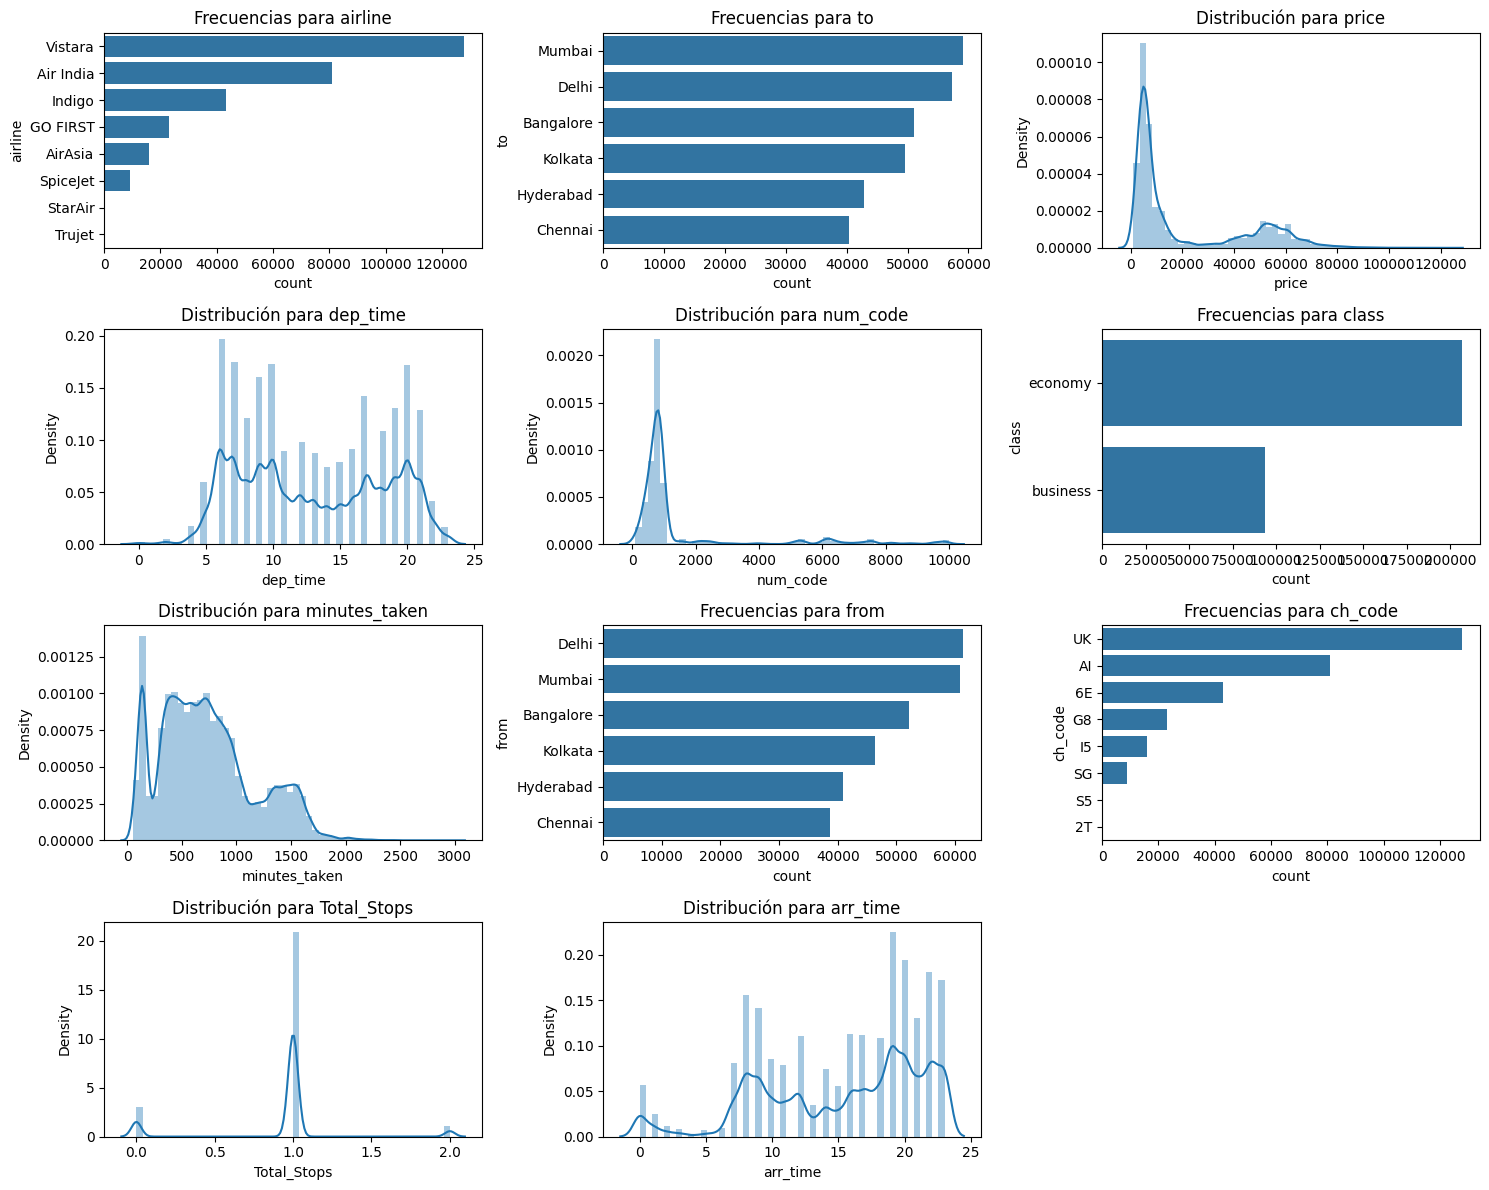

In [ ]:
graficos(calidad_datos(df), df, columnas_graficos)

## Análisis exploratorio (EDA)

### Insights principales

- La variable **price** presenta una distribución sesgada a la derecha, lo que indica la presencia de vuelos significativamente más caros (outliers).
  
- La mayoría de los vuelos pertenecen a la clase **economy**, lo que sugiere un desbalance en la variable categórica que podría influir en el modelo.

- La variable **Total_Stops** muestra que la mayoría de los vuelos tienen **una escala**, siendo menos comunes los vuelos directos o con múltiples escalas.

- La duración del vuelo (**minutes_taken**) presenta una alta variabilidad, lo que sugiere que este factor podría tener un impacto importante en el precio.

- Las aerolíneas como **Vistara** y **Air India** concentran la mayor cantidad de vuelos en el dataset, lo que puede influir en la predicción del modelo.

- Los horarios de salida y llegada (**dep_time** y **arr_time**) están distribuidos a lo largo del día, sin una concentración clara en un solo periodo.

### Interpretación

Estos patrones sugieren que variables como la duración del vuelo, el número de escalas y la aerolínea podrían ser determinantes clave en la predicción del precio de los vuelos.

2022-02-11 00:00:00 ---- 2022-03-31 00:00:00


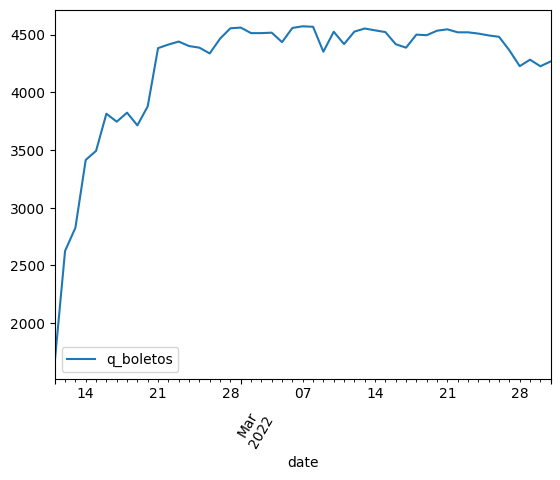

In [ ]:
#Exploramos las fechas
print(df.date.min(), '----', df.date.max())
plt.rcParams.update({'font.size': 10})
df1.groupby('date').agg(q_boletos=('date', 'count')).plot()
plt.xticks(rotation=60)
plt.show()

2022-02-11 00:00:00 ---- 2022-03-31 00:00:00


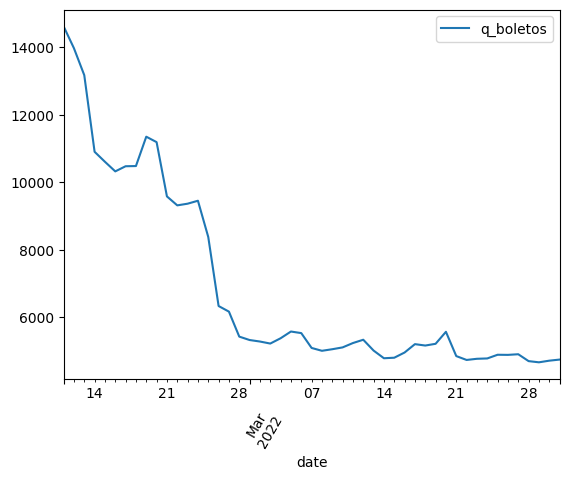

In [ ]:
#Exploramos los precios
print(df.date.min(), '----', df.date.max())
plt.rcParams.update({'font.size': 10})
df1.groupby('date').agg(q_boletos=('price', 'mean')).plot()
plt.xticks(rotation=60)
plt.show()


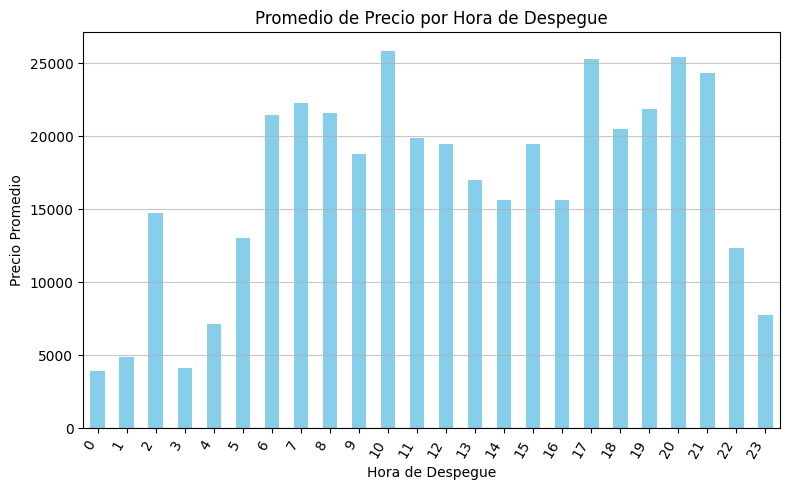

In [ ]:
#Análisis bivariado
promedio_precio_por_hora = df.groupby('dep_time')['price'].mean()
plt.figure(figsize=(8, 5))
promedio_precio_por_hora.plot(kind='bar', color='skyblue')
plt.title('Promedio de Precio por Hora de Despegue')
plt.xlabel('Hora de Despegue')
plt.ylabel('Precio Promedio')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

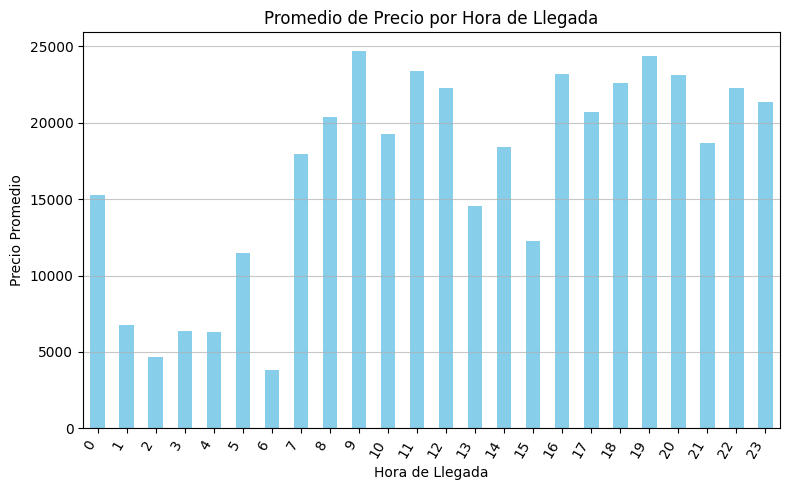

In [ ]:
promedio_precio_por_hora_llegada = df.groupby('arr_time')['price'].mean()
plt.figure(figsize=(8, 5))
promedio_precio_por_hora_llegada.plot(kind='bar', color='skyblue')
plt.title('Promedio de Precio por Hora de Llegada')
plt.xlabel('Hora de Llegada')
plt.ylabel('Precio Promedio')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

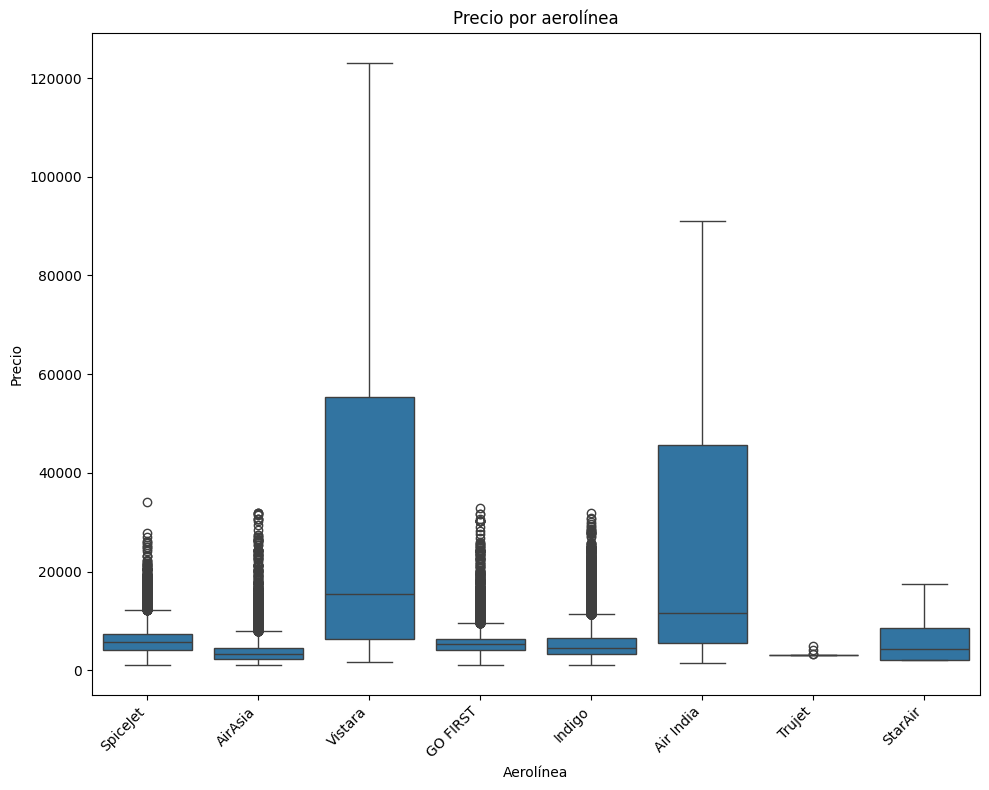

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='airline', y='price', data=df)
plt.xlabel('Aerolínea')
plt.ylabel('Precio')
plt.title('Precio por aerolínea')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

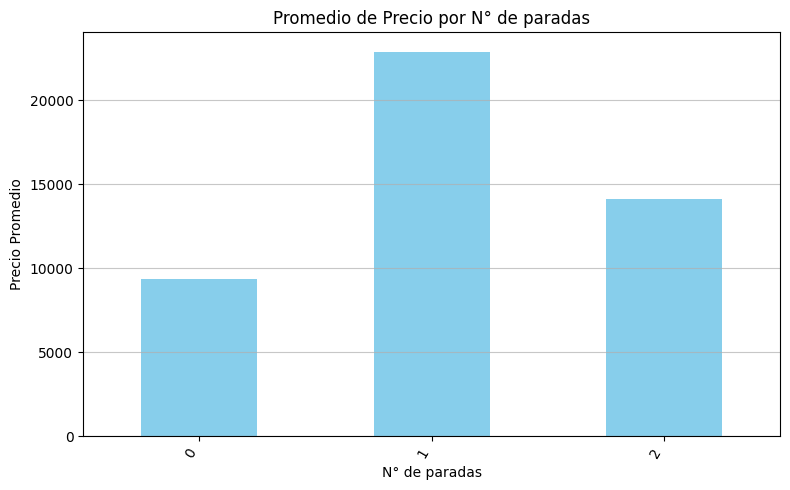

In [ ]:
promedio_precio_escalas = df.groupby('Total_Stops')['price'].mean()
plt.figure(figsize=(8, 5))
promedio_precio_escalas.plot(kind='bar', color='skyblue')
plt.title('Promedio de Precio por N° de paradas')
plt.xlabel('N° de paradas')
plt.ylabel('Precio Promedio')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', alpha=0.7)
plt.tight_layout()
plt.show()

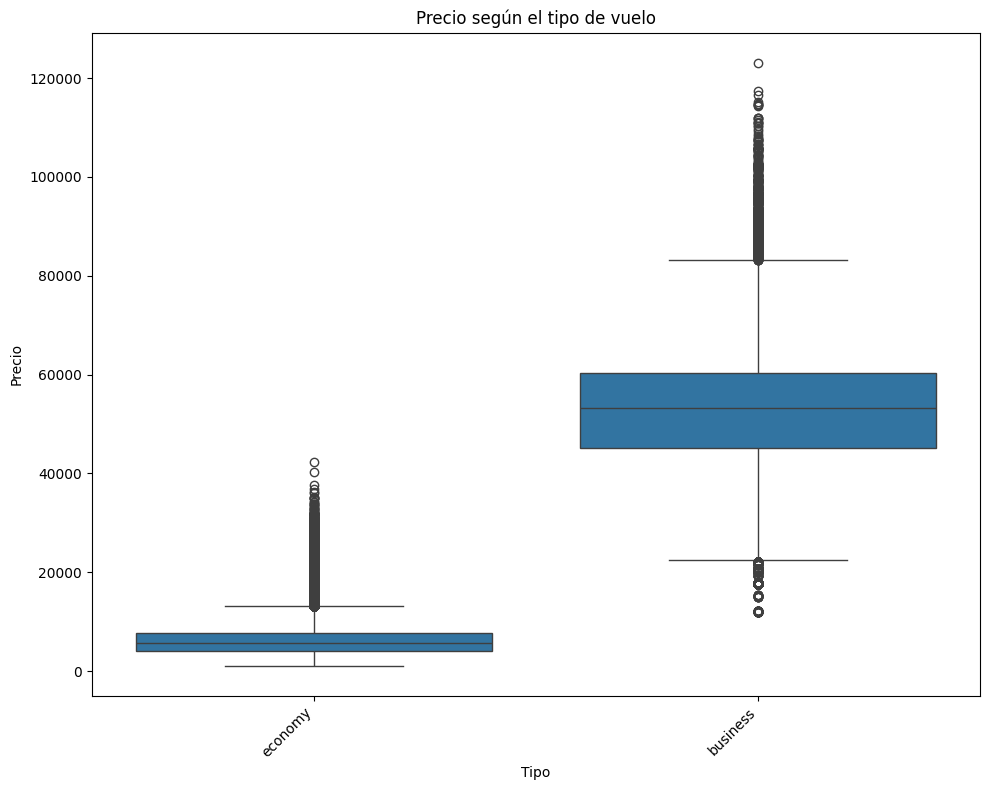

In [ ]:
plt.figure(figsize=(10, 8))
sns.boxplot(x='class', y='price', data=df)
plt.xlabel('Tipo')
plt.ylabel('Precio')
plt.title('Precio según el tipo de vuelo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
df.head()

,date,airline,ch_code,num_code,dep_time,from,arr_time,to,price,class,Total_Stops,minutes_taken
0,2022-02-11,SpiceJet,SG,8709,18,Delhi,21,Mumbai,5953.0,economy,0,130
1,2022-02-11,SpiceJet,SG,8157,6,Delhi,8,Mumbai,5953.0,economy,0,140
2,2022-02-11,AirAsia,I5,764,4,Delhi,6,Mumbai,5956.0,economy,0,130
3,2022-02-11,Vistara,UK,995,10,Delhi,12,Mumbai,5955.0,economy,0,135
4,2022-02-11,Vistara,UK,963,8,Delhi,11,Mumbai,5955.0,economy,0,140


In [ ]:
df.drop("date", axis = 1, inplace = True)

In [ ]:
calidad_datos(df)

,tipo,nan,porcentaje_nan,ceros,porcentaje_ceros,count,unique,top,freq,mean,std,min,25%,50%,75%,max,IQR,lim_inf,lim_sup,atipicos
dep_time,int32,0,0.0,303,0.100913,300259.0,NaN,NaN,NaN,12.983518,5.363199,0.0,8.0,12.0,18.0,23.0,10.0,-7.0,33.0,0
arr_time,int32,0,0.0,7863,2.618739,300259.0,NaN,NaN,NaN,15.238967,6.050235,0.0,10.0,17.0,20.0,23.0,10.0,-5.0,35.0,0
Total_Stops,int32,0,0.0,36044,12.004303,300259.0,NaN,NaN,NaN,0.924212,0.398189,0.0,1.0,1.0,1.0,2.0,0.0,1.0,1.0,49332
minutes_taken,int32,0,0.0,0,0.000000,300259.0,NaN,NaN,NaN,733.06235,431.575411,50.0,405.0,675.0,970.0,2990.0,565.0,-442.5,1817.5,2004
num_code,int64,0,0.0,0,0.000000,300259.0,NaN,NaN,NaN,1417.776883,1974.519951,101.0,637.0,818.0,927.0,9991.0,290.0,202.0,1362.0,49024
price,float64,0,0.0,0,0.000000,300259.0,NaN,NaN,NaN,20883.800386,22695.96223,1105.0,4783.0,7425.0,42521.0,123071.0,37738.0,-51824.0,99128.0,123
airline,object,0,0.0,0,0.000000,300259,8,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
ch_code,object,0,0.0,0,0.000000,300259,8,UK,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
from,object,0,0.0,0,0.000000,300259,6,Delhi,61343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
to,object,0,0.0,0,0.000000,300259,6,Mumbai,59107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


In [ ]:
#Transformación de variables
df_codificado = pd.get_dummies(df, drop_first = True).astype(int)
df_codificado.head()

,num_code,dep_time,arr_time,price,Total_Stops,minutes_taken,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,...,from_Delhi,from_Hyderabad,from_Kolkata,from_Mumbai,to_Chennai,to_Delhi,to_Hyderabad,to_Kolkata,to_Mumbai,class_economy
0,8709,18,21,5953,0,130,0,0,0,1,...,1,0,0,0,0,0,0,0,1,1
1,8157,6,8,5953,0,140,0,0,0,1,...,1,0,0,0,0,0,0,0,1,1
2,764,4,6,5956,0,130,1,0,0,0,...,1,0,0,0,0,0,0,0,1,1
3,995,10,12,5955,0,135,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1
4,963,8,11,5955,0,140,0,0,0,0,...,1,0,0,0,0,0,0,0,1,1


In [ ]:
calidad_datos(df)

,tipo,nan,porcentaje_nan,ceros,porcentaje_ceros,count,unique,top,freq,mean,std,min,25%,50%,75%,max,IQR,lim_inf,lim_sup,atipicos
dep_time,int32,0,0.0,303,0.100913,300259.0,NaN,NaN,NaN,12.983518,5.363199,0.0,8.0,12.0,18.0,23.0,10.0,-7.0,33.0,0
arr_time,int32,0,0.0,7863,2.618739,300259.0,NaN,NaN,NaN,15.238967,6.050235,0.0,10.0,17.0,20.0,23.0,10.0,-5.0,35.0,0
Total_Stops,int32,0,0.0,36044,12.004303,300259.0,NaN,NaN,NaN,0.924212,0.398189,0.0,1.0,1.0,1.0,2.0,0.0,1.0,1.0,49332
minutes_taken,int32,0,0.0,0,0.000000,300259.0,NaN,NaN,NaN,733.06235,431.575411,50.0,405.0,675.0,970.0,2990.0,565.0,-442.5,1817.5,2004
num_code,int64,0,0.0,0,0.000000,300259.0,NaN,NaN,NaN,1417.776883,1974.519951,101.0,637.0,818.0,927.0,9991.0,290.0,202.0,1362.0,49024
price,float64,0,0.0,0,0.000000,300259.0,NaN,NaN,NaN,20883.800386,22695.96223,1105.0,4783.0,7425.0,42521.0,123071.0,37738.0,-51824.0,99128.0,123
airline,object,0,0.0,0,0.000000,300259,8,Vistara,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
ch_code,object,0,0.0,0,0.000000,300259,8,UK,127859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
from,object,0,0.0,0,0.000000,300259,6,Delhi,61343,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
to,object,0,0.0,0,0.000000,300259,6,Mumbai,59107,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0


## Transformación de variables

Las variables categóricas fueron transformadas mediante one-hot encoding, generando variables binarias para cada categoría.

Esto permite que los modelos de machine learning interpreten correctamente la información sin asumir un orden entre categorías.

Se utilizó `drop_first=True` para evitar multicolinealidad.




In [ ]:
columnas_a_escalar = ["price", "minutes_taken"]
data_to_scale = df_codificado[columnas_a_escalar]

# Inicializa el StandardScaler
scaler = StandardScaler()

# Ajusta el escalador a los datos y luego transforma los datos
scaled_data = scaler.fit_transform(data_to_scale)

# Crea un nuevo DataFrame con los datos escalados
scaled_df = pd.DataFrame(scaled_data, columns=columnas_a_escalar, index=df_codificado.index)

# Reemplaza las columnas originales con las versiones escaladas en tu DataFrame
df_codificado[columnas_a_escalar] = scaled_df

In [ ]:
df_codificado.head(2)

,num_code,dep_time,arr_time,price,Total_Stops,minutes_taken,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,...,from_Delhi,from_Hyderabad,from_Kolkata,from_Mumbai,to_Chennai,to_Delhi,to_Hyderabad,to_Kolkata,to_Mumbai,class_economy
0,8709,18,21,-0.657863,0,-1.397353,0,0,0,1,...,1,0,0,0,0,0,0,0,1,1
1,8157,6,8,-0.657863,0,-1.374182,0,0,0,1,...,1,0,0,0,0,0,0,0,1,1


Correlación de Pearson entre num_code y price: -0.21
Correlación de Pearson entre dep_time y price: 0.03
Correlación de Pearson entre arr_time y price: 0.07
Correlación de Pearson entre Total_Stops y price: 0.12
Correlación de Pearson entre minutes_taken y price: 0.20
Correlación de Pearson entre airline_AirAsia y price: -0.18
Correlación de Pearson entre airline_GO FIRST y price: -0.19
Correlación de Pearson entre airline_Indigo y price: -0.28
Correlación de Pearson entre airline_SpiceJet y price: -0.11
Correlación de Pearson entre airline_StarAir y price: -0.01
Correlación de Pearson entre airline_Trujet y price: -0.01
Correlación de Pearson entre airline_Vistara y price: 0.36
Correlación de Pearson entre ch_code_6E y price: -0.28
Correlación de Pearson entre ch_code_AI y price: 0.07
Correlación de Pearson entre ch_code_G8 y price: -0.19
Correlación de Pearson entre ch_code_I5 y price: -0.18
Correlación de Pearson entre ch_code_S5 y price: -0.01
Correlación de Pearson entre ch_code_S

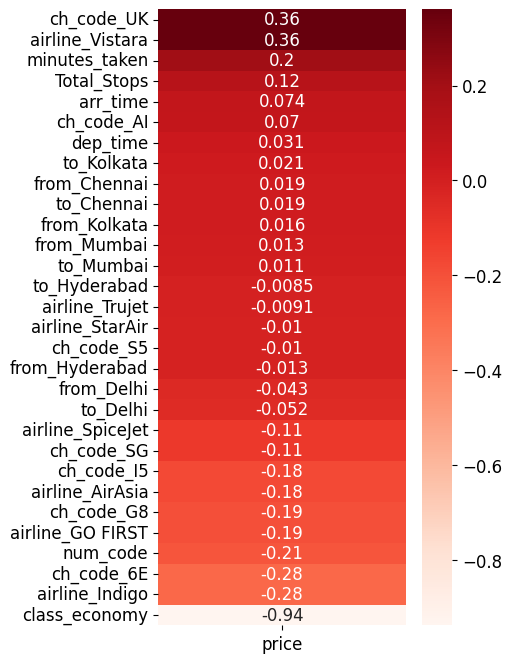

In [ ]:
numeric_features, categorical_features = correlacion(df_codificado, 'price')

## Análisis de correlación

Se analizó la relación entre las variables y el precio del vuelo para identificar los factores más influyentes.

### Hallazgos principales

- La variable **class_economy** presenta una fuerte correlación negativa (-0.94), lo que indica que los vuelos en clase económica tienden a ser significativamente más baratos.

- La aerolínea **Vistara** muestra una correlación positiva con el precio, sugiriendo que sus vuelos tienden a ser más costosos en comparación con otras aerolíneas.

- La duración del vuelo (**minutes_taken**) tiene una correlación positiva, indicando que vuelos más largos suelen tener precios más altos.

- El número de escalas (**Total_Stops**) también influye en el precio, aunque en menor medida.

- Variables como horarios de salida y llegada (**dep_time**, **arr_time**) presentan baja correlación, lo que sugiere que tienen menor impacto en el precio.

### Interpretación

El precio de los vuelos está principalmente influenciado por la clase del boleto, la aerolínea y la duración del vuelo, mientras que otras variables tienen un impacto más limitado.

Desde una perspectiva de negocio, estos resultados indican que la clase del vuelo y la aerolínea son factores clave en la variación de precios, lo cual puede ser útil para segmentar opciones para los clientes según su presupuesto.

Nota: Algunas variables categóricas fueron transformadas mediante encoding, por lo que la correlación debe interpretarse con cautela. Las variables categóricas fueron transformadas mediante one-hot encoding para ser utilizadas en los modelos de machine learning.

In [ ]:
# Filtro por correlaciones

# Calcula matriz de correlación (variables independientes)
correlation_matrix = df_codificado.drop('price', axis = 1).corr().abs()

In [ ]:
# Crea máscara para seleccionar características altamente correlacionadas
upper = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

In [ ]:
to_drop = [column for column in upper.columns if any(upper[column] > 0.7)]

In [ ]:
to_drop

['ch_code_6E',
 'ch_code_G8',
 'ch_code_I5',
 'ch_code_S5',
 'ch_code_SG',
 'ch_code_UK']

In [ ]:
df_codificado.head(2)

,num_code,dep_time,arr_time,price,Total_Stops,minutes_taken,airline_AirAsia,airline_GO FIRST,airline_Indigo,airline_SpiceJet,...,from_Delhi,from_Hyderabad,from_Kolkata,from_Mumbai,to_Chennai,to_Delhi,to_Hyderabad,to_Kolkata,to_Mumbai,class_economy
0,8709,18,21,-0.657863,0,-1.397353,0,0,0,1,...,1,0,0,0,0,0,0,0,1,1
1,8157,6,8,-0.657863,0,-1.374182,0,0,0,1,...,1,0,0,0,0,0,0,0,1,1


In [ ]:
selected_features_correlation = list(df_codificado.columns)
selected_features_correlation.remove('price')
for c in to_drop:
    selected_features_correlation.remove(c)

In [ ]:
selected_features_correlation

['num_code',
 'dep_time',
 'arr_time',
 'Total_Stops',
 'minutes_taken',
 'airline_AirAsia',
 'airline_GO FIRST',
 'airline_Indigo',
 'airline_SpiceJet',
 'airline_StarAir',
 'airline_Trujet',
 'airline_Vistara',
 'ch_code_AI',
 'from_Chennai',
 'from_Delhi',
 'from_Hyderabad',
 'from_Kolkata',
 'from_Mumbai',
 'to_Chennai',
 'to_Delhi',
 'to_Hyderabad',
 'to_Kolkata',
 'to_Mumbai',
 'class_economy']

In [ ]:
#Forward selection
data_feat = df_codificado.drop('price', axis = 1)
target = df_codificado.loc[:, ['price']]

In [ ]:
# Crea un modelo base
base_model = LinearRegression()

# Utiliza Forward Selection para seleccionar características
sfs = SequentialFeatureSelector(base_model, n_features_to_select=20, direction='forward', \
                                scoring='neg_mean_absolute_percentage_error', cv=5)
sfs.fit(data_feat, target)
selected_features_forward = data_feat.columns[sfs.support_]
print("Características seleccionadas por Forward Selection:")
print(selected_features_forward)

Características seleccionadas por Forward Selection:
Index(['dep_time', 'arr_time', 'Total_Stops', 'minutes_taken',
       'airline_AirAsia', 'airline_GO FIRST', 'airline_SpiceJet',
       'airline_StarAir', 'airline_Trujet', 'ch_code_G8', 'ch_code_I5',
       'ch_code_S5', 'ch_code_SG', 'from_Chennai', 'from_Kolkata',
       'to_Chennai', 'to_Hyderabad', 'to_Kolkata', 'to_Mumbai',
       'class_economy'],
      dtype='object')


In [ ]:
#Identifica características presentes en las dos listas

all_selected_features = []

for i in selected_features_correlation:
    if i in selected_features_forward:
        all_selected_features.append(i)

print("\nCaracterísticas presentes en las dos listas:")
all_selected_features


Características presentes en las dos listas:


['dep_time',
 'arr_time',
 'Total_Stops',
 'minutes_taken',
 'airline_AirAsia',
 'airline_GO FIRST',
 'airline_SpiceJet',
 'airline_StarAir',
 'airline_Trujet',
 'from_Chennai',
 'from_Kolkata',
 'to_Chennai',
 'to_Hyderabad',
 'to_Kolkata',
 'to_Mumbai',
 'class_economy']

In [ ]:
# Elimina características no presentes
filtered_data = df_codificado[all_selected_features]

In [ ]:
filtered_data.head(2)

,dep_time,arr_time,Total_Stops,minutes_taken,airline_AirAsia,airline_GO FIRST,airline_SpiceJet,airline_StarAir,airline_Trujet,from_Chennai,from_Kolkata,to_Chennai,to_Hyderabad,to_Kolkata,to_Mumbai,class_economy
0,18,21,0,-1.397353,0,0,1,0,0,0,0,0,0,0,1,1
1,6,8,0,-1.374182,0,0,1,0,0,0,0,0,0,0,1,1


In [ ]:
y = df["price"]
X = filtered_data

In [ ]:
y.head(2)

0    5953.0
1    5953.0
Name: price, dtype: float64

In [ ]:
X.head(2)

,dep_time,arr_time,Total_Stops,minutes_taken,airline_AirAsia,airline_GO FIRST,airline_SpiceJet,airline_StarAir,airline_Trujet,from_Chennai,from_Kolkata,to_Chennai,to_Hyderabad,to_Kolkata,to_Mumbai,class_economy
0,18,21,0,-1.397353,0,0,1,0,0,0,0,0,0,0,1,1
1,6,8,0,-1.374182,0,0,1,0,0,0,0,0,0,0,1,1


In [ ]:
# División en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Define una lista de modelos con sus respectivas grillas de hiperparámetros
models = [
    {
        'name': 'LinearRegression',
        'model': LinearRegression(),
        'params': {}
    },
    {
        'name': 'Ridge',
        'model': Ridge(),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0]}
    },
    {
        'name': 'Lasso',
        'model': Lasso(),
        'params': {'alpha': [0.01, 0.1, 1.0, 10.0]}
    },
    {
        'name': 'ElasticNet',
        'model': ElasticNet(),
        'params': {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]}
    }#,
    #{
     #   'name': 'RandomForestRegressor',
      #  'model': RandomForestRegressor(random_state = 42, n_jobs=-1),
       # 'params': {
        #    'n_estimators': [20, 30, 40],
         #   'max_depth': [None, 10, 15, 20],
          #  'min_samples_split': [2, 5, 10],
           # 'min_samples_leaf': [1, 2, 4]
        #}
    #}
]

In [ ]:
#Optimización de hiperparámetros
# Entrena los modelos y guardar los mejores
best_models = {}

for model_info in models:
    model = model_info['model']
    model_name = model_info['name']
    param_grid = model_info['params']

    grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1)
    grid_search.fit(X_train, y_train)

    # Guarda el mejor modelo
    best_models[model_name] = grid_search.best_estimator_

    # Imprime los mejores hiperparámetros
    print(f"Mejores hiperparámetros para {model_name}: {grid_search.best_params_}")

Mejores hiperparámetros para LinearRegression: {}
Mejores hiperparámetros para Ridge: {'alpha': 0.1}
Mejores hiperparámetros para Lasso: {'alpha': 0.01}
Mejores hiperparámetros para ElasticNet: {'alpha': 0.01, 'l1_ratio': 0.8}


In [ ]:
best_models

{'LinearRegression': LinearRegression(),
 'Ridge': Ridge(alpha=0.1),
 'Lasso': Lasso(alpha=0.01),
 'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.8)}

In [ ]:
#Guardado de modelos entrenados
for model_name, model in best_models.items():
    joblib.dump(model, f"{model_name}_model.pkl")

In [ ]:
# Evaluación

from sklearn.metrics import r2_score
model_names = ["LinearRegression", "Ridge", "Lasso", "ElasticNet"]
#model_names = ["LinearRegression", "Ridge", "Lasso", "ElasticNet", 'RandomForestRegressor']
#models = [best_models["LinearRegression"], best_models["Ridge"], best_models["Lasso"], best_models["ElasticNet"], best_models["RandomForestRegressor"]]
models = [best_models["LinearRegression"], best_models["Ridge"], best_models["Lasso"], best_models["ElasticNet"]]

In [ ]:
# Crea DataFrames para almacenar resultados
results = []

# Calcula métricas para cada modelo y almacenar los resultados
for model_name, model in zip(model_names, models):
    model = model
    y_pred = model.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    results.append(pd.DataFrame({"Model": [model_name], "R^2": [r2]}))

results = pd.concat(results).reset_index(drop=True)
# Mostrar resultados
print("Resultados de evaluación de modelos:")
print(results)

Resultados de evaluación de modelos:
              Model      R^2
0  LinearRegression  0.89907
1             Ridge  0.89907
2             Lasso  0.89907
3        ElasticNet  0.89897


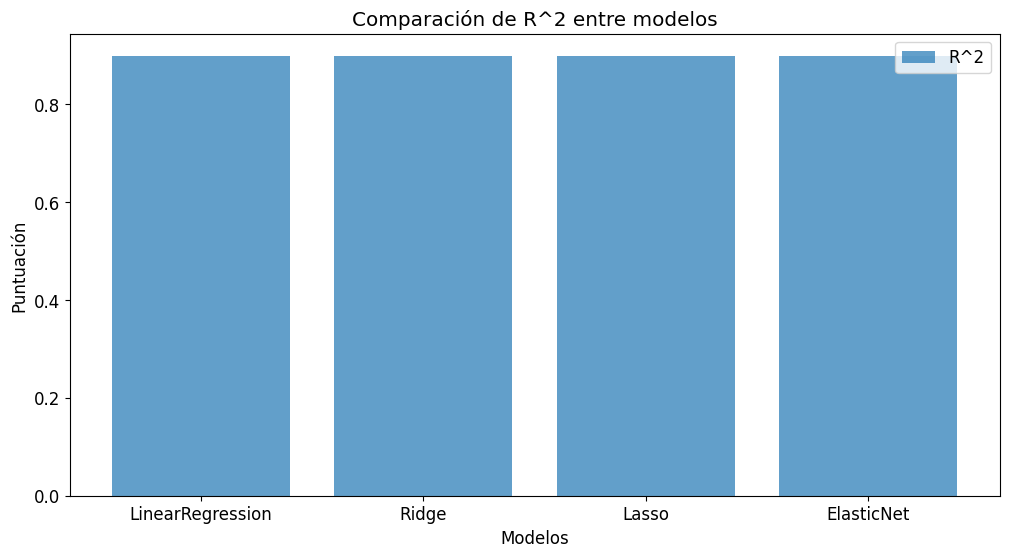

In [ ]:
# Gráfico comparativo
plt.figure(figsize=(12, 6))
plt.bar(results["Model"], results["R^2"], label="R^2", alpha=0.7)
plt.xlabel("Modelos")
plt.ylabel("Puntuación")
plt.title("Comparación de R^2 entre modelos")
plt.legend()
plt.show()


Importancia de las características:
             Feature    Importance
15     class_economy -45081.437893
2        Total_Stops   5959.363877
4    airline_AirAsia  -2866.699743
10      from_Kolkata   2209.311681
13        to_Kolkata   1925.811061
12      to_Hyderabad   -955.703290
5   airline_GO FIRST   -787.642680
9       from_Chennai    681.480319
3      minutes_taken    455.390916
14         to_Mumbai    398.536423
7    airline_StarAir    339.214467
11        to_Chennai    234.484378
8     airline_Trujet   -179.684665
1           arr_time     69.137747
6   airline_SpiceJet    -64.587939
0           dep_time      6.694706


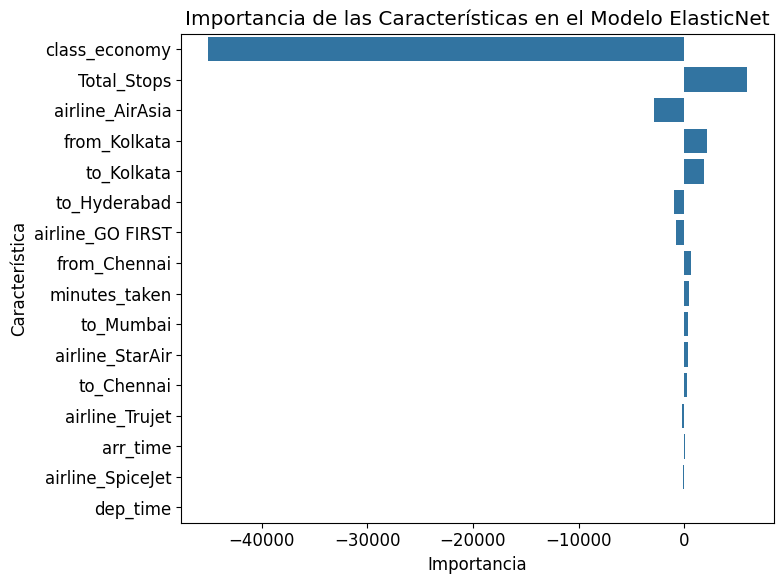

In [ ]:
#Explicabilidad
# Identifica el modelo
model = best_models["ElasticNet"]

# Verifica si el modelo tiene 'feature_importances_' (árboles)
if hasattr(model, "feature_importances_"):
    feature_importances = model.feature_importances_
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importances
    })

# Si no, usar 'coef_' (modelos lineales: ElasticNet, Lasso, Ridge, etc.)
elif hasattr(model, "coef_"):
    feature_importances = model.coef_
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importances
    })
    # Ordenamos por valor absoluto (importancia "real")
    feature_importance_df = feature_importance_df.reindex(
        feature_importance_df.Importance.abs().sort_values(ascending=False).index
    )

# Ordena el DataFrame por importancia en orden descendente
feature_importance_df = feature_importance_df.sort_values(
    by='Importance', key=lambda x: abs(x), ascending=False
)

# Muestra la importancia de las características
print("\nImportancia de las características:")
print(feature_importance_df)

# Visualiza la importancia de las características
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title(f'Importancia de las Características en el Modelo {type(model).__name__}')
plt.xlabel('Importancia')
plt.ylabel('Característica')
plt.tight_layout()
plt.show()

## Conclusiones

El modelo desarrollado logra identificar correctamente los principales factores que influyen en el precio de un vuelo, destacando la clase del boleto, el número de escalas, la aerolínea y la ruta como variables clave.

Se seleccionó el modelo ElasticNet debido a su capacidad de regularización y selección automática de variables, lo que permite obtener un modelo más interpretable sin sacrificar significativamente el desempeño predictivo. Además, los resultados obtenidos son coherentes con el comportamiento esperado en el mundo real, lo que aumenta la confianza en su utilidad.

En términos de negocio, estos hallazgos sugieren que los usuarios pueden encontrar mejores precios optando por vuelos con escalas o en clase económica, mientras que ciertas aerolíneas y rutas tienden a presentar costos más elevados.

## Próximos pasos

- Evaluar modelos basados en árboles (como Random Forest o Gradient Boosting) para capturar relaciones no lineales más complejas.
- Optimizar hiperparámetros para mejorar el desempeño del modelo.
- Validar la capacidad de generalización mediante técnicas más robustas.
- Incorporar nuevas variables relevantes como estacionalidad, anticipación de compra y tipo de día (laborable vs fin de semana).
- Desarrollar un prototipo funcional (API o dashboard) que permita estimar precios de vuelos en un entorno real.

## Conclusión ejecutiva

El modelo demuestra que es posible predecir precios de vuelos de manera consistente utilizando variables operativas clave. Esto abre la posibilidad de implementar soluciones como comparadores de precios o herramientas de recomendación, aportando valor tanto a usuarios como a plataformas de viajes.